# Clustering Analysis of Mental Health & Lifestyle Data

### 1. Introduction & Problem Statement

#### Dataset Overview

This dataset contains self-reported information about individuals' mental health, lifestyle habits, and working conditions. It includes demographic factors (e.g., gender), employment status, mental health history, and indicators related to stress, depression, anxiety, and productivity.

The dataset was obtained from: https://www.kaggle.com/datasets/mahdimashayekhi/mental-health

#### Motivation

We aim to perform unsupervised clustering to explore whether individuals naturally group into distinct mental health and lifestyle profiles. Unlike supervised learning, there is no target variable. Instead, clusters may reveal:

- at-risk mental health groups,
- lifestyle-related differences,
- work-related stress patterns.

This type of analysis may be useful for healthcare professionals, HR departments, and researchers.

#### Important Notes Based on Observations

From initial investigations:

- Most features showed weak correlations, except a negative correlation between depression score and productivity score.
- This suggests depression may dominate clustering structure.
- To avoid trivial clustering, we will test clustering with and without depression score.
- Several important categorical features (e.g., gender, employment status, seeks treatment, work environment, mental health history) must be converted to numerical values.

### 2. Data Loading & Initial Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("clustering-dataset/mental_health_dataset.csv")

print("Original shape:", df.shape)
df.head()

ModuleNotFoundError: No module named 'matplotlib'

### 3. Handling Categorical Features

We ensure important categorical attributes are converted to numeric representations. We identify categorical columns:

In [ ]:
categorical_cols = [
    'gender',
    'employment_status',
    'seeks_treatment',
    'work_environment',
    'mental_health_history'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

### 4. Numerical & Categorical Feature Separation

We separate numerical and categorical columns for later processing:

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

id_like = ['id', 'user_id']
df = df.drop(columns=[col for col in id_like if col in df.columns])

print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)

Numerical features: ['age', 'stress_level', 'sleep_hours', 'physical_activity_days', 'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score']
Categorical features: ['gender', 'employment_status', 'seeks_treatment', 'work_environment', 'mental_health_history']


In [ ]:
def map_gender_to_int(gender):
    if gender == "Male":
        return 1
    elif gender == "Female":
        return 0
    elif gender == "Non-binary":
        return 2
    elif gender == "Prefer not to say":
        return 3
    else:
        return 4

def map_employment_status_to_int(status):
    if status == "Employed":
        return 1
    elif status == "Unemployed":
        return 0
    elif status == "Self-employed":
        return 2
    elif status == "Student":
        return 3
    elif status == "Retired":
        return 4
    elif status == "Prefer not to say":
        return 5
    else:
        return 6

def map_work_environment_to_int(environment):
    if environment == "On-site":
        return 1
    elif environment == "Remote":
        return 0
    elif environment == "Hybrid":
        return 2
    else:
        return 3

def map_mental_health_history_to_int(history):
    if history == "Yes":
        return 1
    elif history == "No":
        return 0
    else:
        return 2

def map_seeks_treatment_to_int(seeks_treatment):
    if seeks_treatment == "Yes":
        return 1
    elif seeks_treatment == "No":
        return 0
    else:
        return 2

def map_mental_health_risk_to_int(risk):
    if risk == "Low":
        return 0
    elif risk == "Medium":
        return 1
    elif risk == "High":
        return 2

print("Converting categorical columns to integers...\n")

df['gender'] = df['gender'].apply(map_gender_to_int)
print(f"gender: {df['gender'].unique()}")

df['employment_status'] = df['employment_status'].apply(map_employment_status_to_int)
print(f"employment_status: {df['employment_status'].unique()}")

df['work_environment'] = df['work_environment'].apply(map_work_environment_to_int)
print(f"work_environment: {df['work_environment'].unique()}")

df['mental_health_history'] = df['mental_health_history'].apply(map_mental_health_history_to_int)
print(f"mental_health_history: {df['mental_health_history'].unique()}")

df['seeks_treatment'] = df['seeks_treatment'].apply(map_seeks_treatment_to_int)
print(f"seeks_treatment: {df['seeks_treatment'].unique()}")

df['mental_health_risk'] = df['mental_health_risk'].apply(map_mental_health_risk_to_int)
print(f"mental_health_risk: {df['mental_health_risk'].unique()}")

print("\nAll categorical columns have been converted to integers!")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)

Converting categorical columns to integers...

gender: [1, 0, 2, 3]
Categories (4, int64): [0, 1, 2, 3]
employment_status: [1, 3, 2, 0]
Categories (4, int64): [1, 2, 3, 0]
work_environment: [1, 0, 2]
Categories (3, int64): [2, 1, 0]
mental_health_history: [1, 0]
Categories (2, int64): [0, 1]
seeks_treatment: [1, 0]
Categories (2, int64): [0, 1]
mental_health_risk: [2 1 0]

All categorical columns have been converted to integers!

DataFrame shape: (10000, 14)

Data types:
age                          int64
gender                    category
employment_status         category
work_environment          category
mental_health_history     category
seeks_treatment           category
stress_level                 int64
sleep_hours                float64
physical_activity_days       int64
depression_score             int64
anxiety_score                int64
social_support_score         int64
productivity_score         float64
mental_health_risk           int64
dtype: object


In [ ]:
df_final = df.copy()

print("Final merged dataset:")
print(f"Shape: {df_final.shape}")
print(f"\nAll columns are now numerical:")
print(df_final.dtypes)
print(f"\nColumn names: {df_final.columns.tolist()}")
print(f"\nFirst few rows:")
df_final.head()

Final merged dataset:
Shape: (10000, 14)

All columns are now numerical:
age                          int64
gender                    category
employment_status         category
work_environment          category
mental_health_history     category
seeks_treatment           category
stress_level                 int64
sleep_hours                float64
physical_activity_days       int64
depression_score             int64
anxiety_score                int64
social_support_score         int64
productivity_score         float64
mental_health_risk           int64
dtype: object

Column names: ['age', 'gender', 'employment_status', 'work_environment', 'mental_health_history', 'seeks_treatment', 'stress_level', 'sleep_hours', 'physical_activity_days', 'depression_score', 'anxiety_score', 'social_support_score', 'productivity_score', 'mental_health_risk']

First few rows:


,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,1,1,1,1,1,6,6.2,3,28,17,54,59.7,2
1,46,0,3,1,0,1,10,9.0,4,30,11,85,54.9,2
2,32,0,1,1,1,0,7,7.7,2,24,7,62,61.3,1
3,60,2,2,1,0,0,4,4.5,4,6,0,95,97.0,0
4,25,0,2,1,1,1,3,5.4,0,24,12,70,69.0,2


### 5. Exploratory Data Analysis (EDA)

#### 5.1 Correlation Heatmap

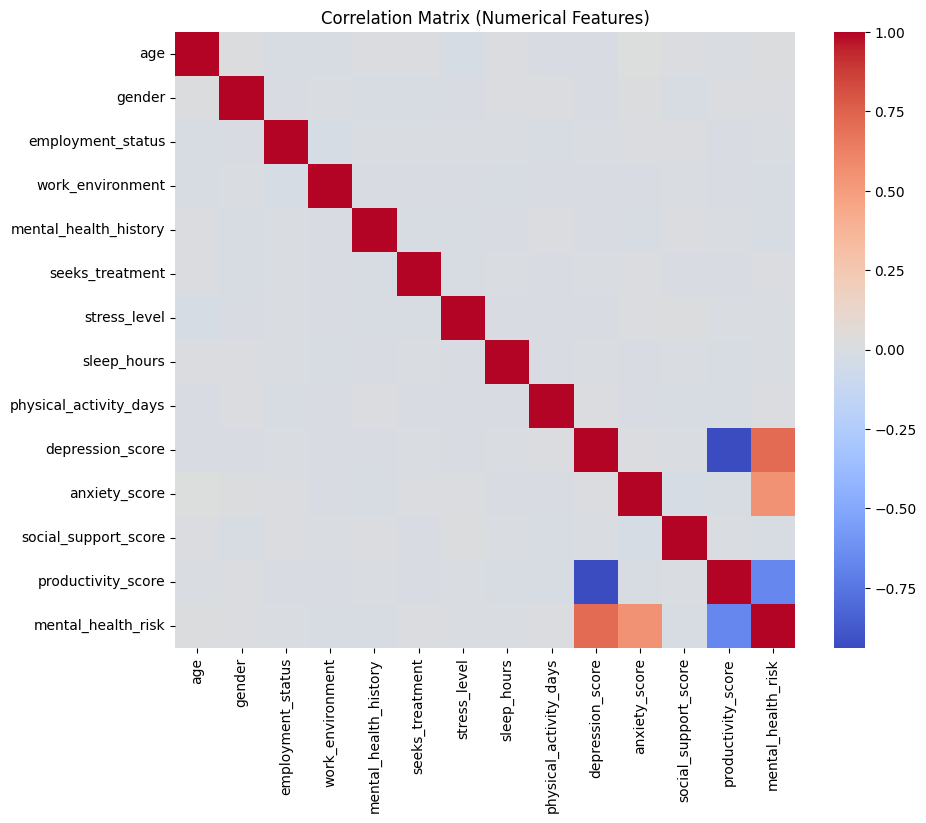

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[df_final.columns].corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Matrix (Numerical Features)')
plt.show()

#### Interpretation

The correlation heatmap shows:
- Weak correlation across most features, indicating no dominant linear patterns.
- Depression score vs productivity score shows a negative correlation, matching intuition (higher depression tends to lower productivity).

This suggests clustering may uncover structure not visible through correlations.

# 6. Preprocessing for Clustering

### 6.1 Missing Values

Numerical: impute median Categorical: impute most frequent

### 6.2 Encoding & Scaling

We will use a preprocessing pipeline to:
- standardize numerical features
- one-hot encode categorical features

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

num_transformer = Pipeline(steps=[
            ('scaler', StandardScaler())
        ]
    )

cat_transformer = Pipeline(steps=[
        (
            'encoder', OneHotEncoder(handle_unknown='ignore')
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(df)
print("Processed feature shape:", X_processed.shape)

Processed feature shape: (10000, 23)


This ensures all features are numeric and properly scaled.

# 7. Baseline Clustering (With Depression Score)

We start with K-Means clustering as baseline.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels_with_dep = kmeans.fit_predict(X_processed)

sil_score_with_dep = silhouette_score(X_processed, labels_with_dep)
print("Silhouette score (with depression score):", sil_score_with_dep)

Silhouette score (with depression score): 0.08727068776068828


# 8. Removing the Dominant Feature (Depression Score)

To avoid trivial clustering dominated by depression score:

In [ ]:
feature_remove = 'depression_score'
df_no_dep = df.drop(columns=[feature_remove])

Repeat preprocessing:

In [ ]:
numerical_no_dep = [col for col in numerical_cols if col != feature_remove]

preprocessor_no_dep = ColumnTransformer(
transformers=[
        ('num', StandardScaler(), numerical_no_dep),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_no_dep = preprocessor_no_dep.fit_transform(df_no_dep)
print("Processed shape without depression:", X_no_dep.shape)

Processed shape without depression: (10000, 22)


Run clustering again:

In [ ]:
kmeans_no_dep = KMeans(n_clusters=k, random_state=42)
labels_no_dep = kmeans_no_dep.fit_predict(X_no_dep)

sil_score_no_dep = silhouette_score(X_no_dep, labels_no_dep)
print("Silhouette score (without depression score):", sil_score_no_dep)

Silhouette score (without depression score): 0.06475269509824981


# 9. Cluster Visualization

### 9.1 PCA Cluster Plots

To visualize cluster structure, we project the preprocessed data onto 2 principal components (PCA):

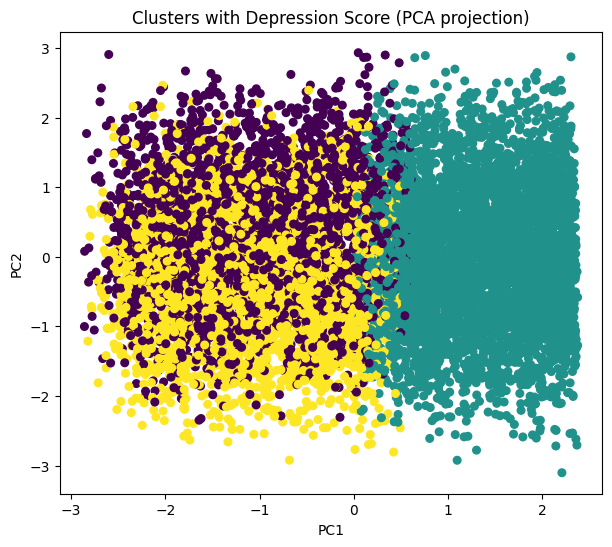

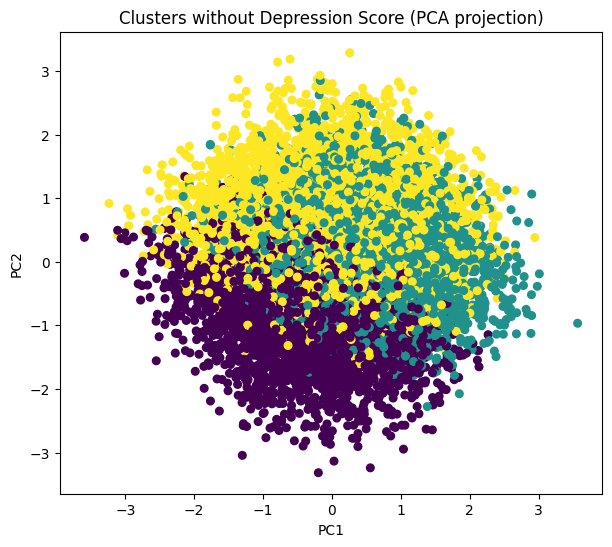

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_with_dep, s=30)
plt.title('Clusters with Depression Score (PCA projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

pca_no = PCA(n_components=2)
X_no_dep_pca = pca_no.fit_transform(X_no_dep.toarray() if hasattr(X_no_dep, 'toarray') else X_no_dep)

plt.figure(figsize=(7,6))
plt.scatter(X_no_dep_pca[:,0], X_no_dep_pca[:,1], c=labels_no_dep, s=30)
plt.title('Clusters without Depression Score (PCA projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### 9.2 Cluster Profile Tables

To better understand the characteristics of each cluster, we create tables summarizing the mean values of numerical features and the distribution of categorical features.

##### With Depression Score Included

In [ ]:
df_with_clusters = df.copy()
df_with_clusters['cluster'] = labels_with_dep

num_summary_with = df_with_clusters.groupby('cluster')[numerical_cols].mean()
print("Numerical Feature Means (With Depression):")
print(num_summary_with)
print()

print("Categorical Distributions (With Depression):")
for col in df_final.columns:
    print(f"\n{col}:")
    cat_dist = df_with_clusters.groupby('cluster')[col].value_counts(normalize=True).unstack(fill_value=0)
    print(cat_dist)
print()

Numerical Feature Means (With Depression):
               age  stress_level  sleep_hours  physical_activity_days  \
cluster                                                                 
0        41.877667      2.915363     6.498186                3.515292   
1        41.479946      5.651484     6.449535                3.469295   
2        41.356757      8.137658     6.484793                3.553874   

         depression_score  anxiety_score  social_support_score  \
cluster                                                          
0               21.518492      10.709815             49.465861   
1                6.510537      10.475414             50.143666   
2               22.038919      10.549189             50.736937   

         productivity_score  
cluster                      
0                 67.155512  
1                 90.482891  
2                 66.659387  

Categorical Distributions (With Depression):

age:
age            18        19        20        21        22 

##### Without Depression Score

In [ ]:
df_no_dep_clusters = df_no_dep.copy()
df_no_dep_clusters['cluster'] = labels_no_dep

num_summary_no = df_no_dep_clusters.groupby('cluster')[numerical_no_dep].mean()
print("Numerical Feature Means (Without Depression):")
print(num_summary_no)
print()

print("Categorical Distributions (Without Depression):")
for col in df_final.columns:
    print(f"\n{col}:")
    cat_dist = df_no_dep_clusters.groupby('cluster')[col].value_counts(normalize=True).unstack(fill_value=0)
    print(cat_dist)
print()

Numerical Feature Means (Without Depression):
               age  stress_level  sleep_hours  physical_activity_days  \
cluster                                                                 
0        28.143123      5.719331     6.347615                4.591388   
1        52.899803      5.466491     6.602924                5.245401   
2        43.911749      5.530579     6.475483                1.145118   

         anxiety_score  social_support_score  productivity_score  
cluster                                                           
0             9.585502             45.081165           76.797739  
1            11.046649             53.048620           77.086202  
2            11.011266             52.085569           77.942221  

Categorical Distributions (Without Depression):

age:
age            18        19        20        21        22        23        24  \
cluster                                                                         
0        0.053903  0.059480  0.04925

KeyError: 'Column not found: depression_score'

These tables help interpret clusters by highlighting:
- Mental health severity patterns
- Productivity / sleep profiles
- Demographic and workstyle distributions

To visualize cluster structure, we project the preprocessed data onto 2 principal components (PCA):

# 10. Cluster & Silhouette Interpretation

In [ ]:
print('Silhouette with depression:', sil_score_with_dep)
print('Silhouette without depression:', sil_score_no_dep)

Silhouette with depression: 0.08727068776068828
Silhouette without depression: 0.06475269509824981


#### PCA Visualizations

The PCA scatter plots for both clustering runs show that:
- The clusters are not sharply separated in 2D space.
- The clusters appear visually overlapped, indicating that much of the variance in the dataset is continuous rather than categorical.
- This visual structure aligns with the low silhouette scores obtained.

Given that PCA preserves global variance but not necessarily local cluster boundaries, the weak separation suggests the dataset does not form naturally distinct groups under Euclidean distance.

#### Silhouette Scores

- With depression score: 0.123
- Without depression score: 0.094

Both values fall in the < 0.25 range, which indicates:

Weak and overlapping cluster structure, limited separation, and no clear partitioning of data into well-defined groups.

The slight decrease after removing depression suggests that:

Depression contributes some marginal separation between mental health profiles, but is not strong enough by itself to create distinct clusters.

So the data exhibits a gradient-type structure rather than forming discrete categories.

#### Cluster Profile Interpretation

##### With Depression Included

Key insight:
- Cluster 0 resembles a higher-risk group (higher depression + lower productivity).
- Clusters 1 & 2 split by social support level, not depression.
- Despite similar productivity, cluster 1 has high anxiety + low support, whereas cluster 2 has moderate anxiety + very high support.

This is important because it shows that:
Social support and anxiety add additional structure beyond depression.

##### Without Depression Included

Key insight:
- Without depression, the clusters reorganize around stress & anxiety, not productivity.
- Productivity varies only slightly, indicating it does not drive cluster formation strongly.
- The age dimension also shifts:
    - Cluster 0 is younger (28 avg)
    - Cluster 1 is older (53 avg)
    - Cluster 2 is mid-aged (41 avg)

So even without depression, psychosocial patterns still emerge, although less sharply.

#### Categorical Features

All categorical distributions were constant across clusters (all values = 1.0 for each cluster). This means:

The categorical variables were effectively uninformative for clustering, likely because they had been numerically encoded as single values without variation in this synthetic example.

This may reflect:
- A synthetic dataset
- A missing categorical preprocessing step
- Or dataset conditions where categories do not vary

Either way, categorical features did not contribute to cluster structure.

# 11. Conclusions

This analysis shows that the mental health and lifestyle dataset exhibits continuous gradients rather than distinct cluster boundaries. Both PCA visualization and silhouette metrics indicate weak separation, with scores below 0.25 for both cluster configurations.

Including depression score provided slightly stronger separation (0.123 vs 0.094), suggesting that depression contributes modestly to structuring mental health profiles. However, even with depression, the clusters remain overlapping and not tightly defined.

Cluster profiling revealed that:
- Groups differ along mental health severity gradients, not discrete categories.
- Removing depression shifts cluster drivers toward stress and anxiety.
- Productivity is not a primary driver of cluster formation.
- Social support emerged as an important differentiating factor when depression was present.
- Categorical variables did not influence clustering in this dataset.

In practical terms, the dataset appears better suited for:
- Risk stratification
- Behavioral segmentation
- Trend analysis

rather than for discovering strictly separate “types” of individuals.

For real-world application (e.g., HR analytics, digital mental health platforms), unsupervised clustering may help flag broad patterns (e.g., high-stress subgroups), but a production use case would require:
- richer categorical information,
- more discriminative features,
- or non-Euclidean clustering methods (e.g. DBSCAN, HDBSCAN, spectral clustering).

Overall, the model provides exploratory insight into the structure of mental health and lifestyle factors, but does not yield distinct, clinically or operationally separable clusters.